# 03 — GraphSAGE and Inductive Learning

GraphSAGE learns a neighborhood aggregation rule that can be reused on new nodes or new graphs with compatible features.

The progression is:

**Transductive vs inductive learning** → **Mean aggregation** → **Concatenation** → **Neighborhood sampling** → **GraphSAGE implementation**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

np.set_printoptions(precision=3,suppress=True)
torch.manual_seed(42)

## 1. Transductive vs inductive learning

### Transductive setting

The graph used during training already contains the nodes that will later be evaluated. Their labels may be hidden, but the graph structure is available.

### Inductive setting

The model must apply its learned rule to **new nodes or new graphs**.

GraphSAGE was designed around this inductive objective.

## 2. Mean neighborhood aggregation

For node $v$:

$$
h_{\mathcal{N}(v)}^{(k)}
=
\operatorname{MEAN}
\left(
\left\{
h_u^{(k-1)}:
u\in\mathcal{N}(v)
\right\}
\right)
$$

Then concatenate the node representation with the neighborhood summary:

$$
h_v^{(k)}
=
\sigma
\left(
W^{(k)}
\left[
h_v^{(k-1)}
\Vert
h_{\mathcal{N}(v)}^{(k)}
\right]
\right)
$$

The symbol $\Vert$ denotes concatenation.

## 3. Complete numerical GraphSAGE example

Suppose:

$$
h_v=
\begin{bmatrix}
2\\
1
\end{bmatrix}
$$

and its three neighbors have:

$$
h_1=
\begin{bmatrix}
1\\
2
\end{bmatrix},
\quad
h_2=
\begin{bmatrix}
3\\
4
\end{bmatrix},
\quad
h_3=
\begin{bmatrix}
5\\
6
\end{bmatrix}
$$

The mean neighborhood vector is:

$$
h_{\mathcal{N}(v)}
=
\frac{1}{3}(h_1+h_2+h_3)
=
\begin{bmatrix}
3\\
4
\end{bmatrix}
$$

Concatenation gives:

$$
[h_v\Vert h_{\mathcal{N}(v)}]
=
\begin{bmatrix}
2\\
1\\
3\\
4
\end{bmatrix}
$$

In [2]:
h_v = np.array([2.0,1.0])
neighbors = np.array([[1.0,2.0],[3.0,4.0],[5.0,6.0]])

neighbor_mean = neighbors.mean(axis=0)
combined = np.concatenate([h_v,neighbor_mean])

W = np.array([
    [0.4,-0.2,0.5,0.1],
    [0.3,0.6,-0.1,0.2]
])

z = W @ combined
h_new = np.maximum(z,0)

print("Neighbor mean:",neighbor_mean)
print("Concatenated vector:",combined)
print("Linear output:",z)
print("ReLU output:",h_new)

Neighbor mean: [3. 4.]
Concatenated vector: [2. 1. 3. 4.]
Linear output: [2.5 1.7]
ReLU output: [2.5 1.7]


## 4. Why neighborhood sampling matters

A high-degree node may have thousands of neighbors.

GraphSAGE can sample a fixed-size neighborhood rather than expanding through every connection. This controls memory and computation.

For example, if the first layer samples 10 neighbors and the second samples 5 neighbors per sampled node, the model uses a bounded local computation rather than the full neighborhood.

In [3]:
rng = np.random.default_rng(42)

all_neighbors = np.arange(100)
sample_size = 10
sampled_neighbors = rng.choice(all_neighbors,size=sample_size,replace=False)

print("Available neighbors:",len(all_neighbors))
print("Sampled neighbors:",sampled_neighbors)

Available neighbors: 100
Sampled neighbors: [96 71  8 60 41 94 68  9 19 82]


## 5. From-scratch mean GraphSAGE layer

This implementation exposes the core mechanism directly.

For each node:

1. calculate the mean neighbor representation,
2. concatenate it with the node's own representation,
3. apply a learned linear transformation.

In [4]:
class MeanGraphSAGELayer(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__()
        self.linear = nn.Linear(2*in_dim,out_dim)

    def forward(self,x,neighbors):
        outputs = []

        for i,neighbor_ids in enumerate(neighbors):
            if len(neighbor_ids) == 0:
                neighbor_mean = torch.zeros_like(x[i])
            else:
                neighbor_mean = x[neighbor_ids].mean(dim=0)

            combined = torch.cat([x[i],neighbor_mean],dim=0)
            outputs.append(self.linear(combined))

        return torch.stack(outputs)

## 6. Verify the layer on a tiny graph

In [5]:
x = torch.tensor([
    [1.0,0.0],
    [0.0,1.0],
    [1.0,1.0],
    [2.0,1.0]
])

neighbor_lists = [
    [1,2],
    [0,2,3],
    [0,1,3],
    [1,2]
]

sage_layer = MeanGraphSAGELayer(2,3)
output = sage_layer(x,neighbor_lists)

print("Input shape:",x.shape)
print("Output shape:",output.shape)
print()
print(output)

Input shape: torch.Size([4, 2])
Output shape: torch.Size([4, 3])

tensor([[1.1524, 0.1301, 0.9927],
        [0.9344, 0.0398, 0.5161],
        [1.3557, 0.0114, 0.8120],
        [1.9497, 0.1214, 1.0667]], grad_fn=<StackBackward0>)


## 7. Reuse the same layer on a graph with a different size

This simple test illustrates an important inductive property: the learned aggregation rule does not require a fixed number of nodes.

In [6]:
new_x = torch.tensor([
    [0.5,1.0],
    [1.0,0.5],
    [1.5,1.0],
    [0.0,2.0],
    [2.0,0.0]
])

new_neighbor_lists = [
    [1,2],
    [0,3],
    [0,4],
    [1,4],
    [2,3]
]

new_output = sage_layer(new_x,new_neighbor_lists)

print("Original graph nodes:",x.shape[0])
print("New graph nodes:",new_x.shape[0])
print("New graph output shape:",new_output.shape)

Original graph nodes: 4
New graph nodes: 5
New graph output shape: torch.Size([5, 3])


## 8. GraphSAGE on Cora

The next section uses PyTorch Geometric's `SAGEConv`.

In [8]:
# Uncomment in Google Colab if needed:
!pip -q install torch-geometric

from torch_geometric.datasets import Planetoid
from torch_geometric.nn import SAGEConv

dataset = Planetoid(root="data/Planetoid",name="Cora")
data = dataset[0]

print(data)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.6 MB/s eta 0:00:00


Processing...


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


Done!


## 9. Two-layer GraphSAGE classifier

In [9]:
class GraphSAGE(nn.Module):
    def __init__(self,in_dim,hidden_dim,out_dim):
        super().__init__()
        self.conv1 = SAGEConv(in_dim,hidden_dim)
        self.conv2 = SAGEConv(hidden_dim,out_dim)

    def forward(self,x,edge_index,return_embedding=False):
        x = self.conv1(x,edge_index)
        x = F.relu(x)
        embedding = x
        x = F.dropout(x,p=0.5,training=self.training)
        x = self.conv2(x,edge_index)

        if return_embedding:
            return x,embedding

        return x

model = GraphSAGE(dataset.num_node_features,32,dataset.num_classes)

## 10. Train GraphSAGE

In [10]:
def accuracy_from_logits(logits,y,mask):
    pred = logits[mask].argmax(dim=1)
    return (pred == y[mask]).float().mean().item()

optimizer = torch.optim.Adam(model.parameters(),lr=0.01,weight_decay=5e-4)
history = {"loss":[],"train_acc":[],"val_acc":[]}

for epoch in range(200):
    model.train()
    optimizer.zero_grad()

    logits = model(data.x,data.edge_index)
    loss = F.cross_entropy(logits[data.train_mask],data.y[data.train_mask])

    loss.backward()
    optimizer.step()

    model.eval()

    with torch.no_grad():
        logits = model(data.x,data.edge_index)

    history["loss"].append(loss.item())
    history["train_acc"].append(accuracy_from_logits(logits,data.y,data.train_mask))
    history["val_acc"].append(accuracy_from_logits(logits,data.y,data.val_mask))

## 11. Training behavior

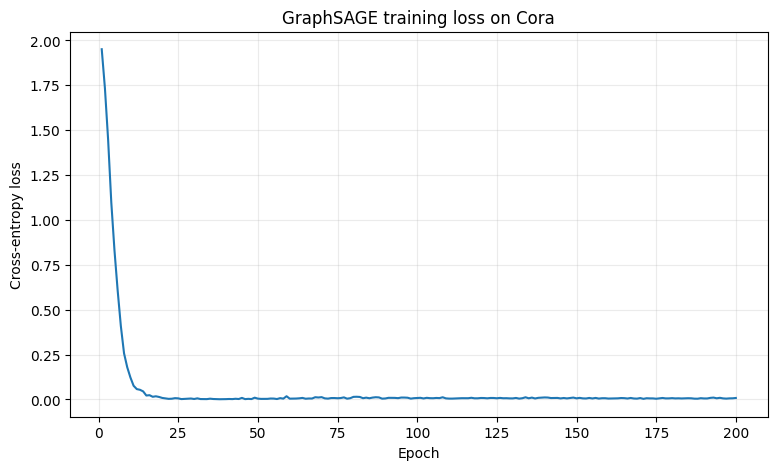

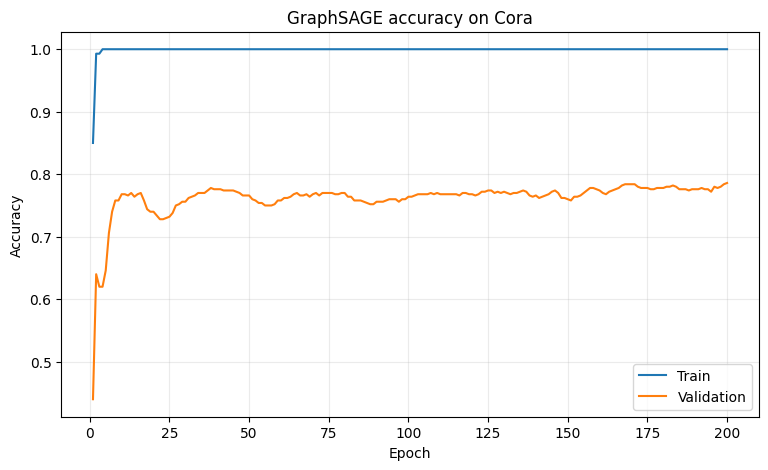

In [11]:
epochs = np.arange(1,len(history["loss"])+1)

plt.figure(figsize=(9,5))
plt.plot(epochs,history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("GraphSAGE training loss on Cora")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(9,5))
plt.plot(epochs,history["train_acc"],label="Train")
plt.plot(epochs,history["val_acc"],label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GraphSAGE accuracy on Cora")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 12. Test evaluation

In [12]:
model.eval()

with torch.no_grad():
    logits,embedding = model(data.x,data.edge_index,return_embedding=True)

test_acc = accuracy_from_logits(logits,data.y,data.test_mask)

print("GraphSAGE test accuracy:",test_acc)

GraphSAGE test accuracy: 0.7900000214576721


## 13. Inspect learned embeddings

The hidden representation is projected to two dimensions only for visualization.

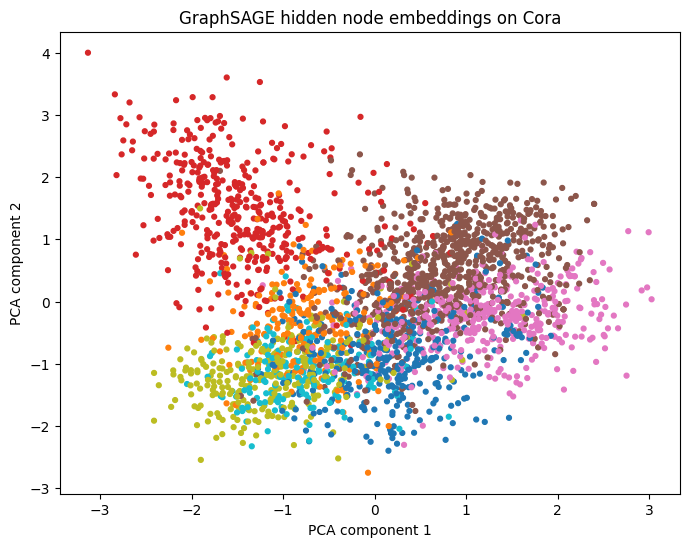

In [13]:
from sklearn.decomposition import PCA

embedding_2d = PCA(n_components=2).fit_transform(embedding.detach().cpu().numpy())

plt.figure(figsize=(8,6))
plt.scatter(embedding_2d[:,0],embedding_2d[:,1],c=data.y.cpu().numpy(),s=12,cmap="tab10")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("GraphSAGE hidden node embeddings on Cora")
plt.show()

## 14. What makes GraphSAGE inductive?

The model learns a **function for combining node and neighborhood features**.

It does not require a separate trainable embedding tied to every node identity.

A new node can therefore be processed when it provides:

- the same type of input features,
- a neighborhood over which the learned aggregation can operate.

The standard Cora experiment above is still a common transductive benchmark split, but the GraphSAGE architecture itself supports inductive use.

## 15. Key takeaways

1. GraphSAGE summarizes neighborhoods using an aggregation function.
2. Mean aggregation converts a variable-size neighborhood into a fixed-size vector.
3. Concatenation preserves both self and neighborhood information.
4. Neighbor sampling can make graph learning scalable.
5. The same learned aggregation rule can be reused on new nodes or graphs with compatible features.
6. The next notebook learns neighbor importance using graph attention.